<a href="https://colab.research.google.com/github/jiyanshud22/Saltmine-Auto-Zoning-and-Stacking/blob/main/heuristic_search_%2B_probabilistic_sampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
"""
Zoning Plan Generator - Python Implementation
Handles adjacency priorities P0-P5, generates synthetic data, and places blocks on 2D grid
"""

import numpy as np
import pandas as pd
import json
import random
from typing import List, Dict, Tuple, Optional
from dataclasses import dataclass, asdict
from collections import defaultdict
import math
from pathlib import Path

# ============ DATA CLASSES ============

@dataclass
class Block:
    """Represents a single block/space in the floor plan"""
    id: str
    name: str
    category: str  # ME, WE, US, SUPPORT, SPECIALTY
    width: int
    height: int
    area: float
    organization: str
    superblock_id: Optional[str] = None
    placed: bool = False
    x: Optional[int] = None
    y: Optional[int] = None

    def to_dict(self):
        return asdict(self)

@dataclass
class BuildingFeature:
    """Represents cores, anchors, and other building features"""
    id: str
    x: int
    y: int
    width: int
    height: int
    type: str  # 'core', 'anchor', 'special'

    def to_dict(self):
        return asdict(self)

@dataclass
class AdjacencyRule:
    """Defines an adjacency constraint between blocks or features"""
    priority: int  # 0-5
    from_block: str
    to_block: str
    relation: str  # 'must_avoid', 'must_be_near', 'preferred_near', 'should_avoid'
    weight: float  # -2 to 1

    def to_dict(self):
        return asdict(self)

@dataclass
class Superblock:
    """Represents a cluster of related blocks"""
    id: str
    blocks: List[Block]
    target_composition: Dict[str, float]
    actual_composition: Dict[str, float]
    composition_match: float

    def to_dict(self):
        return {
            'id': self.id,
            'blocks': [b.to_dict() for b in self.blocks],
            'target_composition': self.target_composition,
            'actual': self.actual_composition,
            'composition_match': self.composition_match
        }

# ============ CONFIGURATION ============

class ZoningConfig:
    """Configuration for block types and adjacency rules"""

    BLOCK_TYPES = {
        'ME': [
            'Individual Zone Work Desks (no partition)',
            'Individual Zone Focus Rooms (1p)',
            'Individual Zone Focus Rooms (2-3p)',
            'Interactive Zone Work Desks (with partitions)',
            'Interactive Zone Focus Rooms (1p)',
            'Interactive Zone Focus Rooms (2-3p)',
            'Individual Zone Touchdown Seats',
            'Interactive Zone Touchdown Seats'
        ],
        'WE': [
            'Individual Zone Phone Booths (Single)',
            'Individual Zone Phone Booths (Double)',
            'Interactive Zone Phone Booths (Single)',
            'Interactive Zone Phone Booths (Double)',
            'Huddle Room (4-6 pax)',
            'Small Meeting (7-9 pax)',
            'Medium Meeting (10-12 pax)',
            'Large Meeting/Boardroom (13-30 pax)'
        ],
        'US': [
            'Restaurant (full-service café)',
            'Coffee Bar (barista-serviced coffee shop)',
            'Alternative Food Points',
            'Flex Space (formerly Agile Space)',
            'Visitor Touchdown'
        ],
        'SUPPORT': [
            'Lockers',
            'Team Storage',
            'Copy/Print',
            'General Storage',
            'Mail/Shipping Center',
            'Kitchen/Pantry (with self-service beverage)',
            'Waste Management',
            'Janitor\'s Closet'
        ],
        'SPECIALTY': [
            'IDF',
            'Server Room',
            'Security Room',
            'Accessibility Lab'
        ]
    }

    # Dimension ranges by category (width_min, width_max, height_min, height_max)
    DIMENSION_RANGES = {
        'ME': (3, 4, 3, 4),
        'WE': (2, 3, 3, 4),
        'US': (5, 10, 5, 10),
        'SUPPORT': (2, 3, 2, 3),
        'SPECIALTY': (3, 3, 3, 3)
    }

    # Target superblock compositions
    SUPERBLOCK_COMPOSITIONS = [
        {'me': 0.60, 'we': 0.25, 'us': 0.10, 'support': 0.05, 'specialty': 0.0},
        {'me': 0.50, 'we': 0.30, 'us': 0.15, 'support': 0.05, 'specialty': 0.0},
        {'me': 0.55, 'we': 0.28, 'us': 0.12, 'support': 0.05, 'specialty': 0.0},
        {'me': 0.65, 'we': 0.20, 'us': 0.10, 'support': 0.05, 'specialty': 0.0},
    ]

    @staticmethod
    def get_adjacency_rules() -> List[AdjacencyRule]:
        """Define all adjacency rules by priority"""
        rules = []

        # Priority 0: Non-compromisable adjacencies
        p0_rules = [
            ('IDF', 'AHU', 'must_avoid', -2),
            ('Server Room', 'AHU', 'must_avoid', -2),
            ('Security Room', 'AHU', 'must_avoid', -2),
            ('IDF', 'Window/Glazing Wall', 'must_avoid', -2),
            ('Server Room', 'Window/Glazing Wall', 'must_avoid', -2),
            ('IDF', 'Toilets', 'must_avoid', -2),
            ('Server Room', 'Toilets', 'must_avoid', -2),
            ('Restaurant (full-service café)', 'Main Entry', 'must_be_near', 1),
            ('Bike Storage/Lockers', 'Service Entry', 'must_be_near', 1),
        ]
        for from_b, to_b, rel, weight in p0_rules:
            rules.append(AdjacencyRule(0, from_b, to_b, rel, weight))

        # Priority 2: Block to Building Feature
        p2_rules = [
            ('IDF', 'Core', 'preferred_near', 0.75),
            ('Server Room', 'Core', 'preferred_near', 0.75),
            ('Restaurant (full-service café)', 'Window/Glazing Wall', 'preferred_near', 0.75),
            ('Coffee Bar (barista-serviced coffee shop)', 'Window/Glazing Wall', 'preferred_near', 0.75),
            ('Lockers', 'Fire Egress', 'preferred_near', 0.5),
        ]
        for from_b, to_b, rel, weight in p2_rules:
            rules.append(AdjacencyRule(2, from_b, to_b, rel, weight))

        # Priority 3: Block to Block
        p3_rules = [
            ('Individual Zone Phone Booths (Single)', 'Individual Zone Work Desks (no partition)', 'should_avoid', -1),
            ('Lockers', 'Individual Zone Work Desks (no partition)', 'should_avoid', -1),
        ]
        for from_b, to_b, rel, weight in p3_rules:
            rules.append(AdjacencyRule(3, from_b, to_b, rel, weight))

        return rules

# ============ DATA GENERATION ============

class SyntheticDataGenerator:
    """Generates synthetic blocks and superblocks"""

    def __init__(self, config: ZoningConfig):
        self.config = config

    def generate_blocks(self, count: int = 100) -> List[Block]:
        """Generate synthetic blocks with realistic dimensions"""
        blocks = []
        block_id = 1

        categories = list(self.config.BLOCK_TYPES.keys())

        for i in range(count):
            category = random.choice(categories)
            block_types = self.config.BLOCK_TYPES[category]
            block_type = random.choice(block_types)

            # Get dimension range for category
            w_min, w_max, h_min, h_max = self.config.DIMENSION_RANGES[category]

            # Generate dimensions with preference for rectangular shapes
            if random.random() < 0.7:  # 70% chance of similar dimensions
                width = random.randint(w_min, w_max)
                height = width if random.random() < 0.5 else random.randint(h_min, h_max)
            else:
                width = random.randint(w_min, w_max)
                height = random.randint(h_min, h_max)

            area = width * height

            block = Block(
                id=f"BLK-{str(block_id).zfill(3)}",
                name=block_type,
                category=category,
                width=width,
                height=height,
                area=area,
                organization="Anchor Resident"
            )

            blocks.append(block)
            block_id += 1

        return blocks

    def generate_superblocks(self, blocks: List[Block]) -> List[Superblock]:
        """Organize blocks into superblocks with target compositions"""
        superblocks = []
        unassigned = blocks.copy()
        superblock_id = 1

        while len(unassigned) > 10 and superblock_id <= 12:
            target_size = random.randint(20, 30)
            target_comp = random.choice(self.config.SUPERBLOCK_COMPOSITIONS)

            # Calculate needed blocks by category
            needed = {
                'ME': int(target_size * target_comp['me']),
                'WE': int(target_size * target_comp['we']),
                'US': int(target_size * target_comp['us']),
                'SUPPORT': int(target_size * target_comp['support']),
                'SPECIALTY': int(target_size * target_comp['specialty'])
            }

            superblock_blocks = []

            # Select blocks for each category
            for category, count in needed.items():
                available = [b for b in unassigned if b.category == category]
                selected = available[:min(count, len(available))]

                for block in selected:
                    block.superblock_id = f"SB-{str(superblock_id).zfill(2)}"
                    superblock_blocks.append(block)
                    unassigned.remove(block)

            if len(superblock_blocks) > 0:
                # Calculate actual composition
                total = len(superblock_blocks)
                actual_comp = {
                    'ME': len([b for b in superblock_blocks if b.category == 'ME']) / total,
                    'WE': len([b for b in superblock_blocks if b.category == 'WE']) / total,
                    'US': len([b for b in superblock_blocks if b.category == 'US']) / total,
                    'SUPPORT': len([b for b in superblock_blocks if b.category == 'SUPPORT']) / total,
                    'SPECIALTY': len([b for b in superblock_blocks if b.category == 'SPECIALTY']) / total,
                }

                # Calculate composition match
                match = self._calculate_composition_match(target_comp, actual_comp)

                superblock = Superblock(
                    id=f"SB-{str(superblock_id).zfill(2)}",
                    blocks=superblock_blocks,
                    target_composition=target_comp,
                    actual_composition=actual_comp,
                    composition_match=match
                )

                superblocks.append(superblock)
                superblock_id += 1

        return superblocks

    def _calculate_composition_match(self, target: Dict, actual: Dict) -> float:
        """Calculate how well actual composition matches target"""
        categories = ['me', 'we', 'us', 'support', 'specialty']
        total_error = 0

        for cat in categories:
            target_val = target.get(cat, 0)
            actual_val = actual.get(cat.upper(), 0)
            error = abs(target_val - actual_val)
            total_error += error

        return max(0, 1 - total_error) * 100

# ============ PLACEMENT ENGINE ============

class PlacementEngine:
    """Places blocks on 2D grid following adjacency constraints"""

    def __init__(self, grid_width: int = 100, grid_height: int = 80):
        self.grid_width = grid_width
        self.grid_height = grid_height
        self.grid = None
        self.building_features = []
        self.adjacency_rules = ZoningConfig.get_adjacency_rules()

    def initialize_grid(self):
        """Initialize empty grid"""
        self.grid = np.full((self.grid_height, self.grid_width), None, dtype=object)

    def place_building_features(self):
        """Place cores, anchors, and other fixed building elements"""
        # Cores
        cores = [
            BuildingFeature('CORE-A', 10, 10, 5, 5, 'core'),
            BuildingFeature('CORE-B', 50, 10, 5, 5, 'core'),
            BuildingFeature('CORE-C', 85, 40, 5, 5, 'core')
        ]

        # Anchors
        anchors = [
            BuildingFeature('MAIN-ENTRY', 45, 0, 8, 3, 'anchor'),
            BuildingFeature('SERVICE-ENTRY', 0, 40, 3, 5, 'anchor'),
            BuildingFeature('FIRE-EGRESS-1', 95, 20, 3, 4, 'anchor'),
            BuildingFeature('FIRE-EGRESS-2', 95, 60, 3, 4, 'anchor')
        ]

        # Special features
        special = [
            BuildingFeature('AHU-1', 20, 5, 4, 3, 'special'),
            BuildingFeature('AHU-2', 70, 5, 4, 3, 'special'),
            BuildingFeature('TOILETS-1', 15, 35, 3, 4, 'special'),
            BuildingFeature('TOILETS-2', 80, 35, 3, 4, 'special')
        ]

        self.building_features = cores + anchors + special

        # Mark features on grid
        for feature in self.building_features:
            self._mark_grid(feature.x, feature.y, feature.width, feature.height, feature.id)

    def _mark_grid(self, x: int, y: int, width: int, height: int, id: str):
        """Mark a region on the grid"""
        for dy in range(height):
            for dx in range(width):
                gx, gy = x + dx, y + dy
                if 0 <= gx < self.grid_width and 0 <= gy < self.grid_height:
                    self.grid[gy, gx] = id

    def can_place_block(self, block: Block, x: int, y: int) -> bool:
        """Check if block can be placed at position"""
        if x + block.width > self.grid_width or y + block.height > self.grid_height:
            return False

        # Check if space is free
        for dy in range(block.height):
            for dx in range(block.width):
                if self.grid[y + dy, x + dx] is not None:
                    return False

        return True

    def evaluate_adjacency(self, block: Block, x: int, y: int) -> float:
        """Evaluate adjacency score for placing block at position"""
        score = 0.0

        # Get applicable rules for this block
        for rule in self.adjacency_rules:
            if block.name == rule.from_block or block.name.startswith(rule.from_block):
                # Find target feature or block
                target_features = [
                    f for f in self.building_features
                    if rule.to_block.upper().replace(' ', '-') in f.id or
                       rule.to_block.lower() in f.type
                ]

                for target in target_features:
                    distance = self._calculate_distance(x, y, target.x, target.y)

                    # Apply rule-based scoring
                    if rule.priority == 0:  # Non-compromisable
                        if rule.relation == 'must_avoid':
                            if distance < 10:
                                score += rule.weight * 10  # Heavy penalty
                            else:
                                score += 2  # Reward for avoiding
                        elif rule.relation == 'must_be_near':
                            if distance < 15:
                                score += abs(rule.weight) * 3
                            elif distance > 30:
                                score -= 5

                    elif rule.priority == 2:  # Preferred
                        if rule.relation == 'preferred_near':
                            if distance < 20:
                                score += rule.weight * 2
                            elif distance < 30:
                                score += rule.weight

                    elif rule.priority == 3:  # Should
                        if rule.relation == 'should_avoid':
                            if distance > 5:
                                score += abs(rule.weight)

        return score

    def place_blocks(self, blocks: List[Block], superblocks: List[Superblock]) -> List[Block]:
        """Place all blocks on grid following adjacency rules"""
        self.initialize_grid()
        self.place_building_features()

        placed_blocks = []

        # Place blocks by superblock
        for sb_idx, superblock in enumerate(superblocks):
            # Determine starting position for this superblock
            start_x = (sb_idx % 3) * 30 + 5
            start_y = (sb_idx // 3) * 25 + 15

            # Sort blocks by priority (ME first, then WE, etc.)
            category_order = ['ME', 'WE', 'US', 'SUPPORT', 'SPECIALTY']
            sorted_blocks = sorted(
                superblock.blocks,
                key=lambda b: category_order.index(b.category) if b.category in category_order else 999
            )

            current_x = start_x
            current_y = start_y
            max_row_height = 0

            for block in sorted_blocks:
                placed = False
                attempts = 0
                max_attempts = 100

                while not placed and attempts < max_attempts:
                    # Check if we need to move to next row
                    if current_x + block.width > self.grid_width - 5:
                        current_x = start_x
                        current_y += max_row_height + 1
                        max_row_height = 0

                    # Check if we've run out of vertical space
                    if current_y + block.height > self.grid_height - 5:
                        break

                    # Can we place here?
                    if self.can_place_block(block, current_x, current_y):
                        # Evaluate adjacency
                        adj_score = self.evaluate_adjacency(block, current_x, current_y)

                        # Place if score is acceptable
                        if adj_score >= -5:  # Threshold for placement
                            self._mark_grid(current_x, current_y, block.width, block.height, block.id)
                            block.x = current_x
                            block.y = current_y
                            block.placed = True
                            placed_blocks.append(block)

                            max_row_height = max(max_row_height, block.height)
                            current_x += block.width + 1
                            placed = True
                        else:
                            current_x += 2
                    else:
                        current_x += 1

                    attempts += 1

        return placed_blocks

    def _calculate_distance(self, x1: int, y1: int, x2: int, y2: int) -> float:
        """Calculate Euclidean distance between two points"""
        return math.sqrt((x2 - x1)**2 + (y2 - y1)**2)

# ============ ANALYSIS ENGINE ============

class AnalysisEngine:
    """Analyzes constraint compliance and generates reports"""

    def __init__(self, blocks: List[Block], superblocks: List[Superblock],
                 building_features: List[BuildingFeature], adjacency_rules: List[AdjacencyRule]):
        self.blocks = blocks
        self.superblocks = superblocks
        self.building_features = building_features
        self.adjacency_rules = adjacency_rules

    def analyze_geometric_rectangularity(self) -> float:
        """Calculate percentage of blocks with good rectangular shape"""
        placed_blocks = [b for b in self.blocks if b.placed]
        if not placed_blocks:
            return 0.0

        rectangular_count = 0
        for block in placed_blocks:
            aspect_ratio = max(block.width, block.height) / min(block.width, block.height)
            if aspect_ratio <= 2.0:
                rectangular_count += 1

        return (rectangular_count / len(placed_blocks)) * 100

    def analyze_adjacency_compliance(self) -> Dict[str, float]:
        """Analyze compliance for each priority level"""
        compliance = {}
        placed_blocks = [b for b in self.blocks if b.placed]

        # Group rules by priority
        rules_by_priority = defaultdict(list)
        for rule in self.adjacency_rules:
            rules_by_priority[rule.priority].append(rule)

        for priority in range(6):
            rules = rules_by_priority[priority]
            if not rules:
                compliance[f'p{priority}'] = 100.0
                continue

            total = 0
            compliant = 0

            for rule in rules:
                blocks_with_rule = [b for b in placed_blocks if b.name == rule.from_block]

                for block in blocks_with_rule:
                    total += 1

                    # Find target features
                    targets = [
                        f for f in self.building_features
                        if rule.to_block.upper().replace(' ', '-') in f.id or
                           rule.to_block.lower() in f.type
                    ]

                    if targets:
                        target = targets[0]
                        distance = math.sqrt((block.x - target.x)**2 + (block.y - target.y)**2)

                        if rule.relation == 'must_avoid' and distance >= 10:
                            compliant += 1
                        elif rule.relation == 'must_be_near' and distance < 15:
                            compliant += 1
                        elif rule.relation == 'preferred_near' and distance < 20:
                            compliant += 1
                        elif rule.relation == 'should_avoid' and distance > 5:
                            compliant += 1

            compliance[f'p{priority}'] = (compliant / total * 100) if total > 0 else 100.0

        return compliance

    def generate_report(self) -> Dict:
        """Generate comprehensive analysis report"""
        placed_blocks = [b for b in self.blocks if b.placed]

        report = {
            'summary': {
                'total_blocks': len(self.blocks),
                'placed_blocks': len(placed_blocks),
                'placement_rate': len(placed_blocks) / len(self.blocks) * 100 if self.blocks else 0,
                'total_superblocks': len(self.superblocks)
            },
            'geometric_rectangularity': self.analyze_geometric_rectangularity(),
            'adjacency_compliance': self.analyze_adjacency_compliance(),
            'superblock_composition': [
                {
                    'id': sb.id,
                    'match': sb.composition_match,
                    'target': sb.target_composition,
                    'actual': sb.actual_composition,
                    'block_count': len(sb.blocks)
                }
                for sb in self.superblocks
            ],
            'violations': self._find_violations(placed_blocks)
        }

        return report

    def _find_violations(self, placed_blocks: List[Block]) -> List[Dict]:
        """Find constraint violations"""
        violations = []

        # Check priority 0 (non-compromisable) rules
        p0_rules = [r for r in self.adjacency_rules if r.priority == 0]

        for rule in p0_rules:
            blocks_with_rule = [b for b in placed_blocks if b.name == rule.from_block]

            for block in blocks_with_rule:
                targets = [
                    f for f in self.building_features
                    if rule.to_block.upper().replace(' ', '-') in f.id
                ]

                if targets:
                    target = targets[0]
                    distance = math.sqrt((block.x - target.x)**2 + (block.y - target.y)**2)

                    if rule.relation == 'must_avoid' and distance < 10:
                        violations.append({
                            'priority': 0,
                            'block': block.id,
                            'rule': f"{rule.from_block} must avoid {rule.to_block}",
                            'distance': round(distance, 2),
                            'status': 'violated'
                        })

        return violations

# ============ EXPORT UTILITIES ============

class DataExporter:
    """Export data to various formats"""

    @staticmethod
    def to_json(blocks: List[Block], superblocks: List[Superblock],
                building_features: List[BuildingFeature], analysis: Dict,
                filename: str = 'zoning_data.json'):
        """Export all data to JSON"""
        data = {
            'blocks': [b.to_dict() for b in blocks],
            'superblocks': [sb.to_dict() for sb in superblocks],
            'building_features': [f.to_dict() for f in building_features],
            'analysis': analysis
        }

        with open(filename, 'w') as f:
            json.dump(data, f, indent=2)

        print(f"Data exported to {filename}")

    @staticmethod
    def to_csv(blocks: List[Block], filename: str = 'blocks.csv'):
        """Export blocks to CSV"""
        df = pd.DataFrame([b.to_dict() for b in blocks])
        df.to_csv(filename, index=False)
        print(f"Blocks exported to {filename}")

    @staticmethod
    def grid_to_csv(grid: np.ndarray, filename: str = 'grid.csv'):
        """Export grid to CSV"""
        df = pd.DataFrame(grid)
        df.to_csv(filename, index=False)
        print(f"Grid exported to {filename}")

# ============ MAIN EXECUTION ============

def main():
    """Main execution function"""
    print("=" * 60)
    print("ZONING PLAN GENERATOR")
    print("=" * 60)

    # Initialize
    config = ZoningConfig()
    generator = SyntheticDataGenerator(config)
    placement_engine = PlacementEngine(grid_width=100, grid_height=80)

    # Generate synthetic data
    print("\n1. Generating synthetic blocks...")
    blocks = generator.generate_blocks(count=100)
    print(f"   Generated {len(blocks)} blocks")

    print("\n2. Creating superblocks...")
    superblocks = generator.generate_superblocks(blocks)
    print(f"   Created {len(superblocks)} superblocks")

    # Place blocks
    print("\n3. Placing blocks on grid...")
    placed_blocks = placement_engine.place_blocks(blocks, superblocks)
    print(f"   Placed {len(placed_blocks)}/{len(blocks)} blocks ({len(placed_blocks)/len(blocks)*100:.1f}%)entwicklers)")

    # Analyze
    print("\n4. Analyzing constraints...")
    analyzer = AnalysisEngine(
        blocks, superblocks,
        placement_engine.building_features,
        placement_engine.adjacency_rules
    )
    analysis = analyzer.generate_report()

    # Print summary
    print("\n" + "=" * 60)
    print("ANALYSIS SUMMARY")
    print("=" * 60)
    print(f"\nGeometric Rectangularity: {analysis['geometric_rectangularity']:.1f}%")
    print(f"\nAdjacency Compliance:")
    for priority, score in analysis['adjacency_compliance'].items():
        print(f"  {priority.upper()}: {score:.1f}%")

    print(f"\nSuperblock Composition Matches:")
    for sb in analysis['superblock_composition'][:5]:
        print(f"  {sb['id']}: {sb['match']:.1f}% (ME: {sb['actual']['ME']*100:.0f}%, WE: {sb['actual']['WE']*100:.0f}%)")

    if analysis['violations']:
        print(f"\nConstraint Violations: {len(analysis['violations'])}")
        for v in analysis['violations'][:3]:
            print(f"  - {v['block']}: {v['rule']}")
    else:
        print("\nNo critical violations found!")

    # Export data
    print("\n5. Exporting data...")
    exporter = DataExporter()

    output_dir = Path('/content/outputs')
    output_dir.mkdir(parents=True, exist_ok=True)

    exporter.to_json(blocks, superblocks, placement_engine.building_features,
                     analysis, output_dir / 'zoning_data.json')
    exporter.to_csv(blocks, output_dir / 'blocks.csv')
    exporter.grid_to_csv(placement_engine.grid, output_dir / 'grid.csv')

    print("\n" + "=" * 60)
    print("COMPLETE!")
    print("=" * 60)

    return blocks, superblocks, placement_engine, analysis

if __name__ == "__main__":
    blocks, superblocks, placement_engine, analysis = main()

ZONING PLAN GENERATOR

1. Generating synthetic blocks...
   Generated 100 blocks

2. Creating superblocks...
   Created 12 superblocks

3. Placing blocks on grid...
   Placed 68/100 blocks (68.0%)entwicklers)

4. Analyzing constraints...

ANALYSIS SUMMARY

Geometric Rectangularity: 100.0%

Adjacency Compliance:
  P0: 0.0%
  P1: 100.0%
  P2: 0.0%
  P3: 0.0%
  P4: 100.0%
  P5: 100.0%

Superblock Composition Matches:
  SB-01: 96.2% (ME: 62%, WE: 24%)
  SB-02: 30.0% (ME: 20%, WE: 53%)
  SB-03: 0.0% (ME: 0%, WE: 62%)
  SB-04: 0.0% (ME: 0%, WE: 57%)
  SB-05: 0.0% (ME: 0%, WE: 25%)

No critical violations found!

5. Exporting data...
Data exported to /content/outputs/zoning_data.json
Blocks exported to /content/outputs/blocks.csv
Grid exported to /content/outputs/grid.csv

COMPLETE!


ZONING PLAN VISUALIZER

Generating visualizations...
------------------------------------------------------------
Grid visualization saved to /content/outputs/zoning_plan.png
Superblock analysis saved to /content/outputs/superblock_analysis.png
Compliance dashboard saved to /content/outputs/compliance_dashboard.png
------------------------------------------------------------
All visualizations complete!

VISUALIZATION COMPLETE!


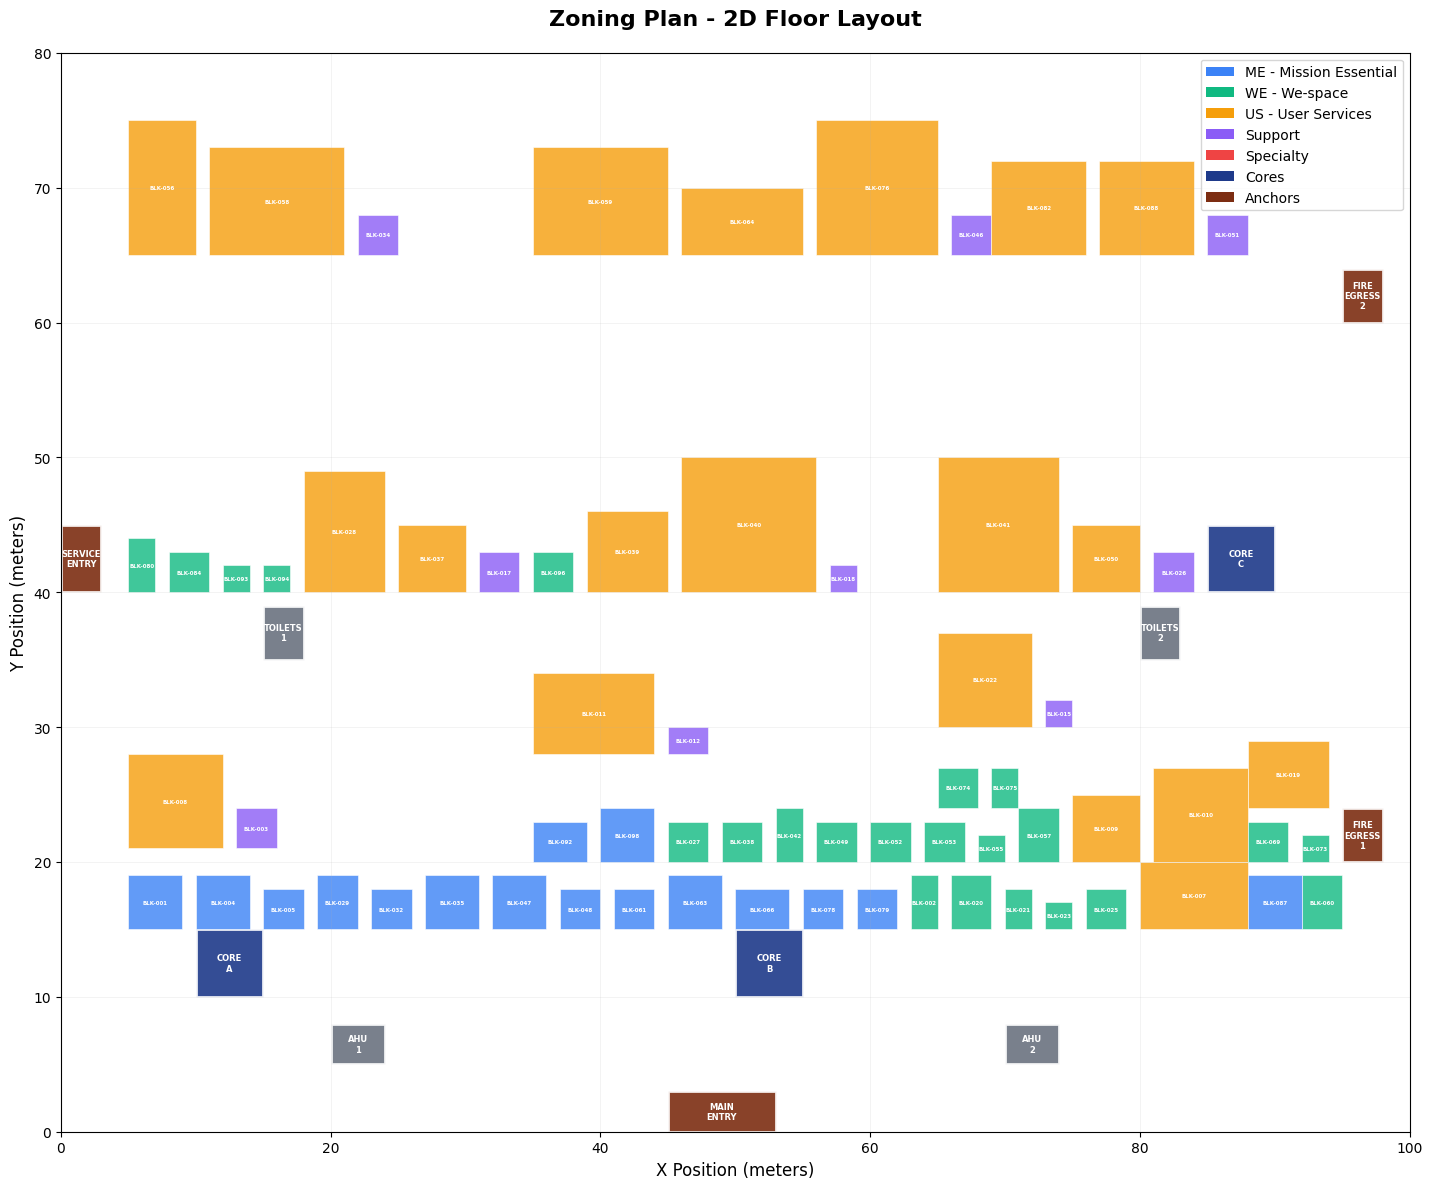

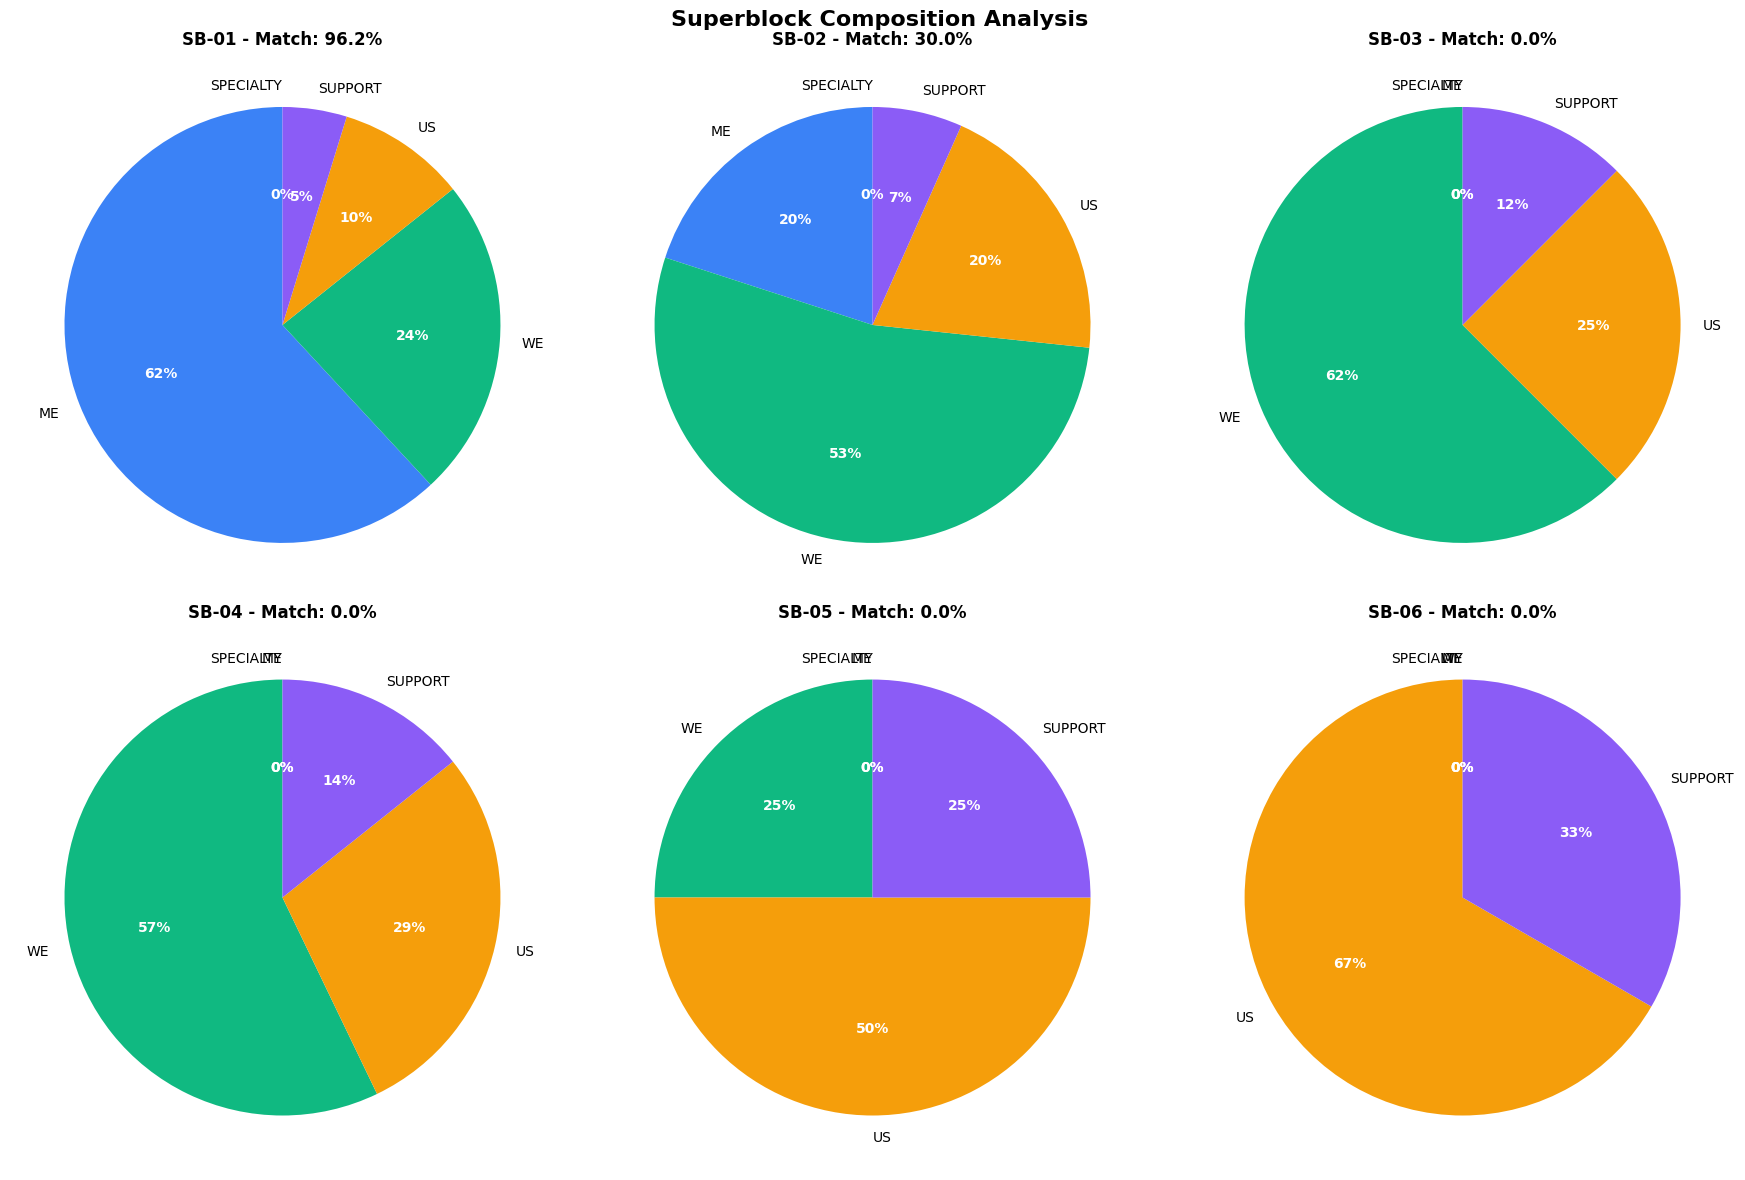

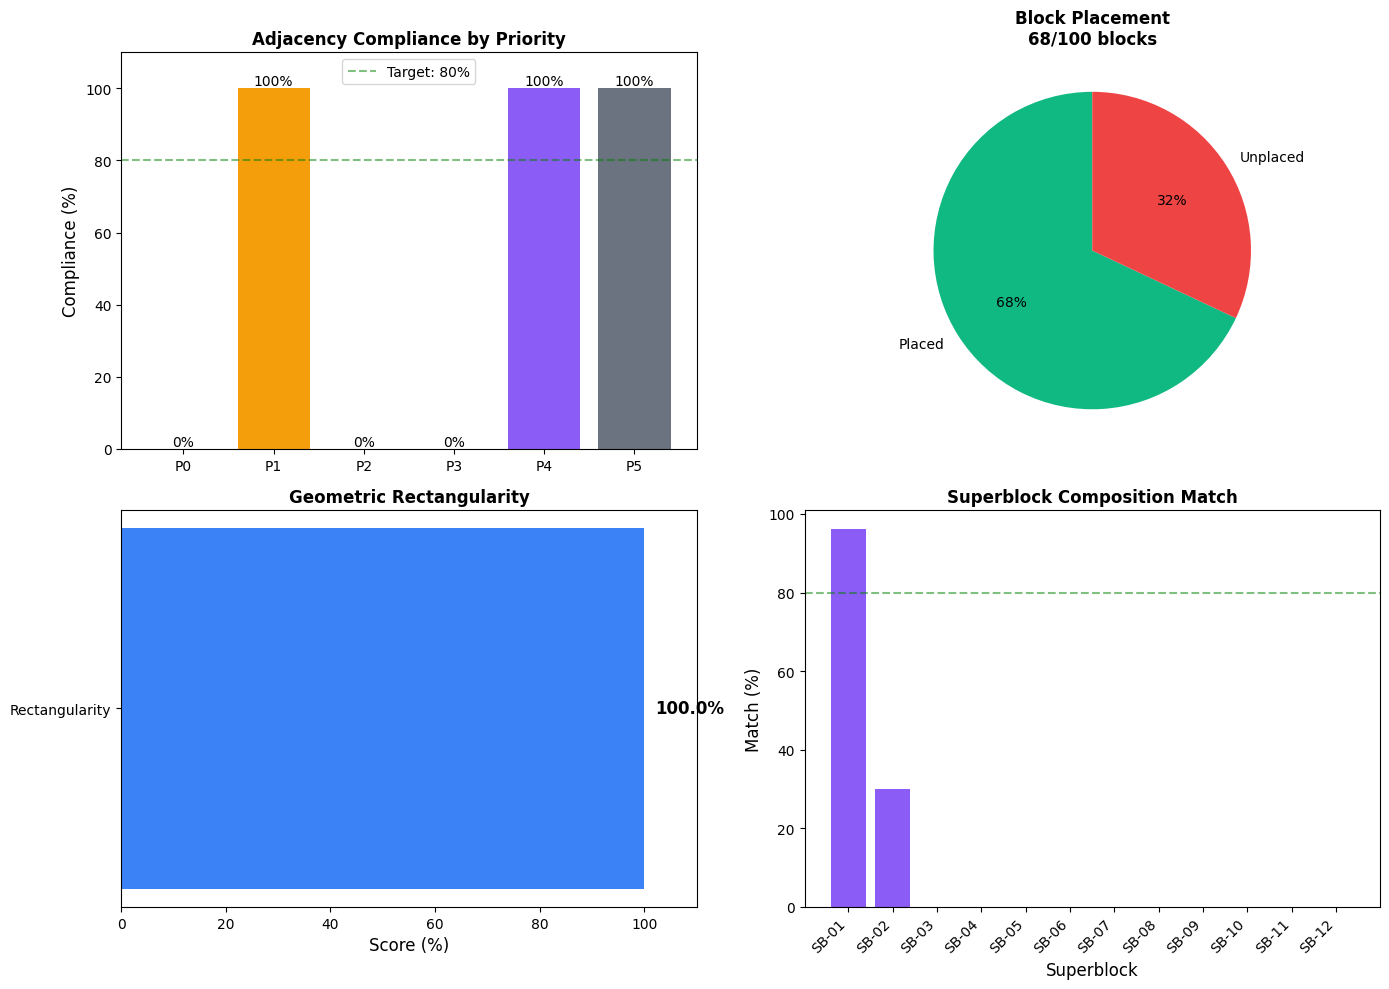

In [12]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Rectangle
import json
from typing import Dict, List

class ZoningVisualizer:
    """Visualize zoning plan using matplotlib"""

    def __init__(self, data_file: str = '/content/outputs/zoning_data.json'):
        """Load data from JSON file"""
        with open(data_file, 'r') as f:
            self.data = json.load(f)

        self.blocks = self.data['blocks']
        self.building_features = self.data['building_features']
        self.superblocks = self.data['superblocks']
        self.analysis = self.data['analysis']

        # Color mapping
        self.colors = {
            'ME': '#3b82f6',      # Blue
            'WE': '#10b981',      # Green
            'US': '#f59e0b',      # Orange
            'SUPPORT': '#8b5cf6', # Purple
            'SPECIALTY': '#ef4444', # Red
            'core': '#1e3a8a',    # Dark blue
            'anchor': '#7c2d12',  # Brown
            'special': '#6b7280'  # Gray
        }

    def plot_grid(self, figsize=(16, 12), save_path='/content/outputs/zoning_plan.png'):
        """Create main grid visualization"""
        fig, ax = plt.subplots(figsize=figsize)

        # Set limits
        ax.set_xlim(0, 100)
        ax.set_ylim(0, 80)
        ax.set_aspect('equal')

        # Plot building features first (they're below)
        for feature in self.building_features:
            color = self.colors.get(feature['type'], '#cccccc')
            rect = Rectangle(
                (feature['x'], feature['y']),
                feature['width'],
                feature['height'],
                linewidth=2,
                edgecolor='white',
                facecolor=color,
                alpha=0.9
            )
            ax.add_patch(rect)

            # Add label
            cx = feature['x'] + feature['width'] / 2
            cy = feature['y'] + feature['height'] / 2
            ax.text(cx, cy, feature['id'].replace('-', '\n'),
                   ha='center', va='center', fontsize=6,
                   color='white', weight='bold')

        # Plot blocks
        for block in self.blocks:
            if block['placed']:
                color = self.colors.get(block['category'], '#cccccc')
                rect = Rectangle(
                    (block['x'], block['y']),
                    block['width'],
                    block['height'],
                    linewidth=0.5,
                    edgecolor='white',
                    facecolor=color,
                    alpha=0.8
                )
                ax.add_patch(rect)

                # Add block ID
                cx = block['x'] + block['width'] / 2
                cy = block['y'] + block['height'] / 2
                ax.text(cx, cy, block['id'],
                       ha='center', va='center', fontsize=4,
                       color='white', weight='bold')

        # Grid
        ax.grid(True, alpha=0.2, linewidth=0.5)
        ax.set_xlabel('X Position (meters)', fontsize=12)
        ax.set_ylabel('Y Position (meters)', fontsize=12)
        ax.set_title('Zoning Plan - 2D Floor Layout', fontsize=16, weight='bold', pad=20)

        # Add legend
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor=self.colors['ME'], label='ME - Mission Essential'),
            Patch(facecolor=self.colors['WE'], label='WE - We-space'),
            Patch(facecolor=self.colors['US'], label='US - User Services'),
            Patch(facecolor=self.colors['SUPPORT'], label='Support'),
            Patch(facecolor=self.colors['SPECIALTY'], label='Specialty'),
            Patch(facecolor=self.colors['core'], label='Cores'),
            Patch(facecolor=self.colors['anchor'], label='Anchors'),
        ]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Grid visualization saved to {save_path}")

        return fig, ax

    def plot_superblock_analysis(self, save_path='/content/outputs/superblock_analysis.png'):
        """Plot superblock composition analysis"""
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        axes = axes.flatten()

        for idx, sb in enumerate(self.superblocks[:6]):
            ax = axes[idx]

            # Data for pie chart
            categories = ['ME', 'WE', 'US', 'SUPPORT', 'SPECIALTY']
            values = [sb['actual'].get(cat, 0) * 100 for cat in categories]
            colors_list = [self.colors[cat] for cat in categories]

            # Create pie chart
            wedges, texts, autotexts = ax.pie(
                values,
                labels=categories,
                colors=colors_list,
                autopct='%1.0f%%',
                startangle=90
            )

            # Style
            for autotext in autotexts:
                autotext.set_color('white')
                autotext.set_weight('bold')
                autotext.set_fontsize(10)

            match = sb['composition_match']
            ax.set_title(f"{sb['id']} - Match: {match:.1f}%",
                        fontsize=12, weight='bold')

        # Overall title
        fig.suptitle('Superblock Composition Analysis', fontsize=16, weight='bold')
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Superblock analysis saved to {save_path}")

        return fig

    def plot_compliance_dashboard(self, save_path='/content/outputs/compliance_dashboard.png'):
        """Plot compliance metrics dashboard"""
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        # 1. Adjacency compliance by priority
        ax1 = axes[0, 0]
        priorities = ['P0', 'P1', 'P2', 'P3', 'P4', 'P5']
        compliance_values = [
            self.analysis['adjacency_compliance'].get(p.lower(), 0)
            for p in priorities
        ]

        bars = ax1.bar(priorities, compliance_values,
                      color=['#ef4444', '#f59e0b', '#10b981', '#3b82f6', '#8b5cf6', '#6b7280'])
        ax1.set_ylabel('Compliance (%)', fontsize=12)
        ax1.set_title('Adjacency Compliance by Priority', fontsize=12, weight='bold')
        ax1.set_ylim(0, 110)
        ax1.axhline(y=80, color='green', linestyle='--', alpha=0.5, label='Target: 80%')
        ax1.legend()

        # Add value labels
        for bar in bars:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.0f}%', ha='center', va='bottom', fontsize=10)

        # 2. Placement statistics
        ax2 = axes[0, 1]
        summary = self.analysis['summary']
        placed = summary['placed_blocks']
        total = summary['total_blocks']
        unplaced = total - placed

        ax2.pie([placed, unplaced],
               labels=['Placed', 'Unplaced'],
               colors=['#10b981', '#ef4444'],
               autopct='%1.0f%%',
               startangle=90)
        ax2.set_title(f"Block Placement\n{placed}/{total} blocks",
                     fontsize=12, weight='bold')

        # 3. Geometric rectangularity
        ax3 = axes[1, 0]
        rect_score = self.analysis['geometric_rectangularity']
        ax3.barh(['Rectangularity'], [rect_score], color='#3b82f6')
        ax3.set_xlim(0, 110)
        ax3.set_xlabel('Score (%)', fontsize=12)
        ax3.set_title('Geometric Rectangularity', fontsize=12, weight='bold')
        ax3.text(rect_score + 2, 0, f'{rect_score:.1f}%',
                va='center', fontsize=12, weight='bold')

        # 4. Superblock matches
        ax4 = axes[1, 1]
        sb_matches = [sb.get('match', sb.get('composition_match', 0)) for sb in self.analysis['superblock_composition']]
        sb_ids = [sb['id'] for sb in self.analysis['superblock_composition']]

        bars = ax4.bar(range(len(sb_matches)), sb_matches, color='#8b5cf6')
        ax4.set_ylabel('Match (%)', fontsize=12)
        ax4.set_xlabel('Superblock', fontsize=12)
        ax4.set_title('Superblock Composition Match', fontsize=12, weight='bold')
        ax4.set_xticks(range(len(sb_ids)))
        ax4.set_xticklabels(sb_ids, rotation=45, ha='right')
        ax4.axhline(y=80, color='green', linestyle='--', alpha=0.5)

        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Compliance dashboard saved to {save_path}")

        return fig

    def generate_all_visualizations(self):
        """Generate all visualization outputs"""
        print("\nGenerating visualizations...")
        print("-" * 60)

        self.plot_grid()
        self.plot_superblock_analysis()
        self.plot_compliance_dashboard()

        print("-" * 60)
        print("All visualizations complete!")

def main():
    """Main visualization function"""
    print("=" * 60)
    print("ZONING PLAN VISUALIZER")
    print("=" * 60)

    visualizer = ZoningVisualizer()
    visualizer.generate_all_visualizations()

    print("\n" + "=" * 60)
    print("VISUALIZATION COMPLETE!")
    print("=" * 60)

if __name__ == "__main__":
    main()
